# MNIST Digit Classifier - Multi-Layer Perceptron (MLP)

## Project Overview

This notebook demonstrates how to build and train a simple Multi-Layer Perceptron (MLP) to classify handwritten digits from the MNIST dataset using PyTorch.

### Learning Objectives:
- Flattening images for MLP input
- Implementing train/validation loops
- Using cross-entropy loss for multi-class classification
- Computing accuracy metrics
- Understanding the complete ML workflow from problem definition to deployment

### Dataset:
- **MNIST**: 28×28 grayscale images of handwritten digits (0-9)
- **Input**: 784 features (flattened 28×28 image)
- **Output**: 10 classes (digits 0-9)

---


## Part 1: Problem Definition

### Understanding the Task

**Problem Type**: Multi-class classification
- **Input**: 28×28 grayscale images of handwritten digits
- **Output**: Class label (0-9)
- **Goal**: Predict the digit shown in the image with high accuracy

### Key Considerations:
1. **Image Format**: Grayscale images need to be flattened from 2D (28×28) to 1D (784)
2. **Class Imbalance**: MNIST is well-balanced, but we should verify
3. **Evaluation Metric**: Accuracy is primary, but we'll also track loss
4. **Baseline**: Random guessing = 10% accuracy (we aim for >95%)

### Success Criteria:
- Training accuracy > 95%
- Validation accuracy > 95%
- Generalization to unseen test data


## Part 2: Data Collection

### MNIST Dataset

The MNIST dataset is a classic benchmark in machine learning:
- **60,000 training images**
- **10,000 test images**
- **10 classes** (digits 0-9)
- **28×28 pixels** per image
- **Grayscale** (single channel)

PyTorch provides easy access to MNIST through `torchvision.datasets`.


In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, Dict, List
import time

# Custom implementations to avoid sklearn dependency issues
def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, labels: List[int] = None) -> np.ndarray:
    """
    Compute confusion matrix without sklearn dependency.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        labels: List of all possible labels (if None, inferred from data)
        
    Returns:
        Confusion matrix as numpy array
    """
    if labels is None:
        labels = sorted(list(set(y_true) | set(y_pred)))
    
    n_classes = len(labels)
    cm = np.zeros((n_classes, n_classes), dtype=int)
    
    label_to_idx = {label: idx for idx, label in enumerate(labels)}
    
    for true, pred in zip(y_true, y_pred):
        true_idx = label_to_idx[true]
        pred_idx = label_to_idx[pred]
        cm[true_idx, pred_idx] += 1
    
    return cm


def classification_report(y_true: np.ndarray, y_pred: np.ndarray, 
                         target_names: List[str] = None, 
                         output_dict: bool = False) -> Dict:
    """
    Generate classification report without sklearn dependency.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        target_names: Names for each class
        output_dict: If True, return as dictionary
        
    Returns:
        Classification report as dictionary
    """
    labels = sorted(list(set(y_true) | set(y_pred)))
    n_classes = len(labels)
    
    if target_names is None:
        target_names = [str(label) for label in labels]
    
    # Calculate metrics for each class
    report = {}
    total_precision = 0
    total_recall = 0
    total_f1 = 0
    
    for i, label in enumerate(labels):
        tp = np.sum((y_true == label) & (y_pred == label))
        fp = np.sum((y_true != label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        support = np.sum(y_true == label)
        
        report[target_names[i]] = {
            'precision': precision,
            'recall': recall,
            'f1-score': f1,
            'support': support
        }
        
        total_precision += precision
        total_recall += recall
        total_f1 += f1
    
    # Calculate averages
    report['macro avg'] = {
        'precision': total_precision / n_classes,
        'recall': total_recall / n_classes,
        'f1-score': total_f1 / n_classes,
        'support': len(y_true)
    }
    
    # Weighted averages
    weighted_precision = sum(report[name]['precision'] * report[name]['support'] 
                            for name in target_names) / len(y_true)
    weighted_recall = sum(report[name]['recall'] * report[name]['support'] 
                         for name in target_names) / len(y_true)
    weighted_f1 = sum(report[name]['f1-score'] * report[name]['support'] 
                     for name in target_names) / len(y_true)
    
    report['weighted avg'] = {
        'precision': weighted_precision,
        'recall': weighted_recall,
        'f1-score': weighted_f1,
        'support': len(y_true)
    }
    
    # Accuracy
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    report['accuracy'] = accuracy
    
    return report

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Download and load MNIST dataset
def load_mnist_data(root: str = './data', batch_size: int = 64) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    Load MNIST dataset and create data loaders.
    
    Args:
        root: Root directory for storing the dataset
        batch_size: Number of samples per batch
        
    Returns:
        Tuple of (train_loader, val_loader, test_loader)
    """
    # Define transformations
    # For MLP, we need to flatten images, so we use transforms.ToTensor() 
    # which converts PIL Image to tensor and normalizes to [0, 1]
    transform = transforms.Compose([
        transforms.ToTensor(),  # Converts PIL Image to tensor and scales to [0, 1]
        # Note: We'll flatten in the model, not in preprocessing
    ])
    
    # Load training dataset
    train_dataset = datasets.MNIST(
        root=root,
        train=True,
        download=True,
        transform=transform
    )
    
    # Split training data into train and validation (80-20 split)
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(
        train_dataset, 
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )
    
    # Load test dataset
    test_dataset = datasets.MNIST(
        root=root,
        train=False,
        download=True,
        transform=transform
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )
    
    return train_loader, val_loader, test_loader

# Load the data
train_loader, val_loader, test_loader = load_mnist_data(batch_size=64)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Using device: cpu
Training batches: 750
Validation batches: 188
Test batches: 157


## Part 3: Data Understanding

Let's explore the dataset to understand its characteristics.



Training Dataset Exploration
Batch size: 64
Image shape: torch.Size([64, 1, 28, 28])
Image tensor shape: torch.Size([64, 1, 28, 28])
Image pixel range: [0.000, 1.000]
Labels shape: torch.Size([64])
Labels range: [0, 9]
Number of classes: 10


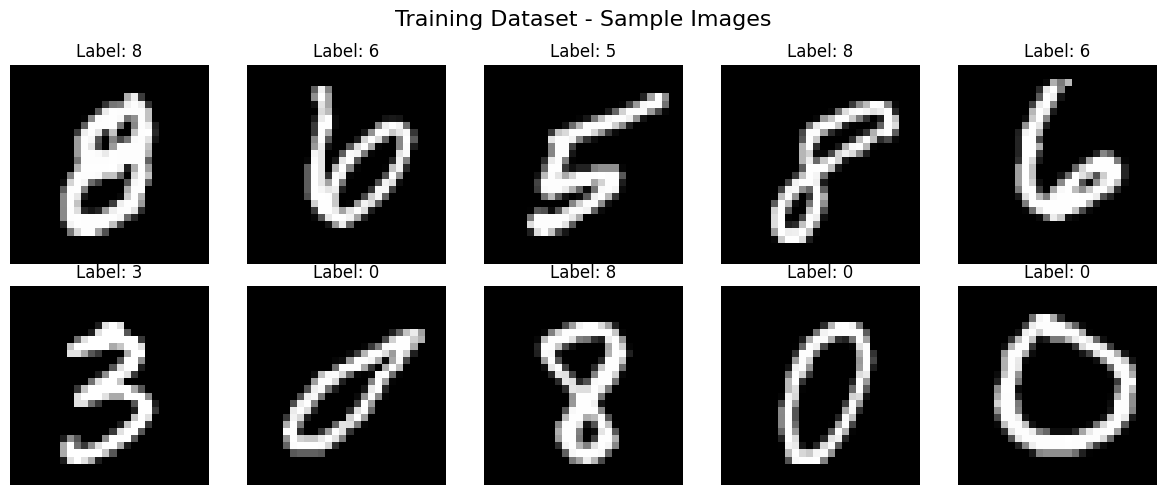


Class Distribution:
  Class 0: 4735 samples (9.9%)
  Class 1: 5383 samples (11.2%)
  Class 2: 4762 samples (9.9%)
  Class 3: 4886 samples (10.2%)
  Class 4: 4681 samples (9.8%)
  Class 5: 4368 samples (9.1%)
  Class 6: 4752 samples (9.9%)
  Class 7: 4983 samples (10.4%)
  Class 8: 4674 samples (9.7%)
  Class 9: 4776 samples (10.0%)


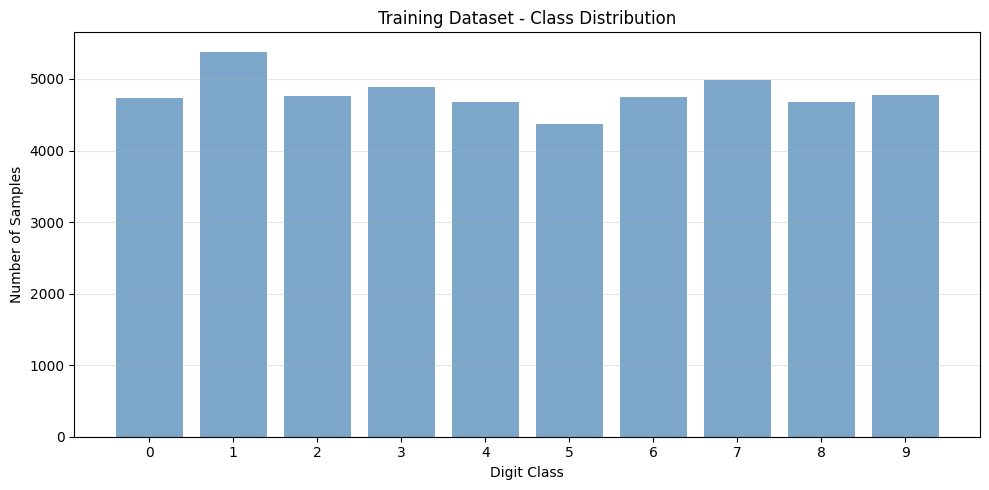

In [2]:
def explore_dataset(data_loader: DataLoader, dataset_name: str = "Dataset") -> None:
    """
    Explore and visualize dataset characteristics.
    
    Args:
        data_loader: DataLoader to explore
        dataset_name: Name of the dataset for display
    """
    # Get a batch of data
    data_iter = iter(data_loader)
    images, labels = next(data_iter)
    
    print(f"\n{'='*60}")
    print(f"{dataset_name} Exploration")
    print(f"{'='*60}")
    print(f"Batch size: {images.shape[0]}")
    print(f"Image shape: {images.shape}")  # [batch_size, channels, height, width]
    print(f"Image tensor shape: {images.shape}")
    print(f"Image pixel range: [{images.min():.3f}, {images.max():.3f}]")
    print(f"Labels shape: {labels.shape}")
    print(f"Labels range: [{labels.min()}, {labels.max()}]")
    print(f"Number of classes: {len(torch.unique(labels))}")
    
    # Visualize some samples
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(f'{dataset_name} - Sample Images', fontsize=16)
    
    for idx in range(10):
        row = idx // 5
        col = idx % 5
        img = images[idx].squeeze()  # Remove channel dimension for grayscale
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(f'Label: {labels[idx].item()}')
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Class distribution
    all_labels = []
    for _, labels_batch in data_loader:
        all_labels.extend(labels_batch.numpy())
    
    unique, counts = np.unique(all_labels, return_counts=True)
    print(f"\nClass Distribution:")
    for cls, count in zip(unique, counts):
        print(f"  Class {cls}: {count} samples ({count/len(all_labels)*100:.1f}%)")
    
    # Plot class distribution
    plt.figure(figsize=(10, 5))
    plt.bar(unique, counts, color='steelblue', alpha=0.7)
    plt.xlabel('Digit Class')
    plt.ylabel('Number of Samples')
    plt.title(f'{dataset_name} - Class Distribution')
    plt.xticks(unique)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Explore training data
explore_dataset(train_loader, "Training Dataset")


In [3]:
# Check image statistics for normalization
def calculate_dataset_statistics(data_loader: DataLoader) -> Dict[str, float]:
    """
    Calculate mean and std of the dataset for normalization.
    
    Args:
        data_loader: DataLoader to analyze
        
    Returns:
        Dictionary with mean and std values
    """
    mean = 0.0
    std = 0.0
    total_samples = 0
    
    for images, _ in data_loader:
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_samples += batch_samples
    
    mean /= total_samples
    std /= total_samples
    
    return {'mean': mean.item(), 'std': std.item()}

stats = calculate_dataset_statistics(train_loader)
print(f"Dataset Statistics:")
print(f"  Mean: {stats['mean']:.4f}")
print(f"  Std: {stats['std']:.4f}")
print(f"\nNote: MNIST images are already normalized to [0, 1] by ToTensor()")
print(f"Standard normalization (mean=0.1307, std=0.3081) can improve training.")


Dataset Statistics:
  Mean: 0.1307
  Std: 0.3016

Note: MNIST images are already normalized to [0, 1] by ToTensor()
Standard normalization (mean=0.1307, std=0.3081) can improve training.


## Part 4: Data Preprocessing

### Preprocessing Steps:

1. **Normalization**: Scale pixel values to [0, 1] (handled by `ToTensor()`)
2. **Flattening**: Convert 2D images (28×28) to 1D vectors (784) - done in model
3. **Optional**: Standard normalization (mean=0, std=1) can help training

### Why Normalize?
- Neural networks train better when inputs are in a similar range
- Prevents gradient issues during backpropagation
- Speeds up convergence


In [4]:
# Update data loading with normalization
def load_mnist_data_normalized(root: str = './data', batch_size: int = 64) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    Load MNIST dataset with normalized preprocessing.
    
    Args:
        root: Root directory for storing the dataset
        batch_size: Number of samples per batch
        
    Returns:
        Tuple of (train_loader, val_loader, test_loader)
    """
    # Normalize using MNIST statistics
    # Mean and std are precomputed for MNIST
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))  # (mean, std) for single channel
    ])
    
    # Load training dataset
    train_dataset = datasets.MNIST(
        root=root,
        train=True,
        download=True,
        transform=transform
    )
    
    # Split training data into train and validation (80-20 split)
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(
        train_dataset, 
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )
    
    # Load test dataset
    test_dataset = datasets.MNIST(
        root=root,
        train=False,
        download=True,
        transform=transform
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )
    
    return train_loader, val_loader, test_loader

# Reload with normalization
train_loader, val_loader, test_loader = load_mnist_data_normalized(batch_size=64)

# Verify normalization
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f"After normalization:")
print(f"  Image pixel range: [{images.min():.3f}, {images.max():.3f}]")
print(f"  Image mean: {images.mean():.4f}")
print(f"  Image std: {images.std():.4f}")


After normalization:
  Image pixel range: [-0.424, 2.821]
  Image mean: 0.0101
  Image std: 1.0124


## Part 5: Cross-Validation

### Train-Validation-Test Split

We've already split the data:
- **Training Set**: 48,000 samples (80% of 60,000) - Used to train the model
- **Validation Set**: 12,000 samples (20% of 60,000) - Used to tune hyperparameters
- **Test Set**: 10,000 samples - Used for final evaluation (never seen during training)

### Why Three Sets?
1. **Training Set**: Learn model parameters
2. **Validation Set**: Monitor overfitting, tune hyperparameters, select best model
3. **Test Set**: Unbiased estimate of model performance on unseen data

### K-Fold Cross-Validation (Optional)
For small datasets, K-fold CV is recommended. MNIST is large enough that a single validation split is sufficient.


## Part 6: Model Selection

### MLP Architecture Design

For MNIST classification, we need to design an MLP that:
1. Takes 784 inputs (flattened 28×28 image)
2. Processes through hidden layers
3. Outputs 10 logits (one per class)

### Design Decisions:

#### 1. **Number of Hidden Layers**
- **Shallow (1-2 layers)**: Simple, fast, may underfit
- **Deep (3+ layers)**: More capacity, risk of overfitting
- **Decision**: Start with 2-3 hidden layers (good balance)

#### 2. **Hidden Layer Sizes**
- **Too small**: Limited capacity, may underfit
- **Too large**: Risk of overfitting, slower training
- **Common pattern**: Gradually decrease (e.g., 512 → 256 → 128)
- **Decision**: Use 512 → 256 → 128 (proven to work well for MNIST)

#### 3. **Activation Functions**
- **ReLU**: Most common, addresses vanishing gradient
- **Sigmoid/Tanh**: Older, can suffer from vanishing gradients
- **Decision**: ReLU for hidden layers, no activation on output (raw logits)

#### 4. **Output Layer**
- **10 neurons** (one per class)
- **No activation** (raw logits) - CrossEntropyLoss includes Softmax

#### 5. **Regularization**
- **Dropout**: Prevents overfitting by randomly zeroing neurons
- **Decision**: Add dropout (0.2-0.5) between hidden layers

### Architecture Summary:
```
Input (784) 
  → Hidden 1 (512) + ReLU + Dropout
  → Hidden 2 (256) + ReLU + Dropout  
  → Hidden 3 (128) + ReLU + Dropout
  → Output (10) [no activation]
```


In [5]:
class MNISTMLP(nn.Module):
    """
    Multi-Layer Perceptron for MNIST digit classification.
    
    Architecture:
    - Input: 784 features (flattened 28×28 image)
    - Hidden layers: 512 → 256 → 128 neurons
    - Output: 10 classes (digits 0-9)
    - Activation: ReLU for hidden layers
    - Regularization: Dropout
    
    Args:
        input_size: Number of input features (default: 784 for MNIST)
        hidden_sizes: List of hidden layer sizes (default: [512, 256, 128])
        num_classes: Number of output classes (default: 10)
        dropout_rate: Dropout probability (default: 0.3)
    """
    
    def __init__(
        self, 
        input_size: int = 784,
        hidden_sizes: List[int] = None,
        num_classes: int = 10,
        dropout_rate: float = 0.3
    ):
        super(MNISTMLP, self).__init__()
        
        if hidden_sizes is None:
            hidden_sizes = [512, 256, 128]
        
        # Build layers dynamically
        layers = []
        prev_size = input_size
        
        # Hidden layers
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        # Output layer (no activation - CrossEntropyLoss includes Softmax)
        layers.append(nn.Linear(prev_size, num_classes))
        
        # Create sequential model
        self.model = nn.Sequential(*layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the network.
        
        Args:
            x: Input tensor of shape (batch_size, 1, 28, 28) or (batch_size, 784)
            
        Returns:
            Output tensor of shape (batch_size, num_classes)
        """
        # Flatten the input if it's 2D (batch_size, 1, 28, 28)
        if x.dim() > 2:
            x = x.view(x.size(0), -1)  # Flatten to (batch_size, 784)
        
        return self.model(x)
    
    def count_parameters(self) -> int:
        """
        Count the number of trainable parameters in the model.
        
        Returns:
            Total number of parameters
        """
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Create model instance
model = MNISTMLP(
    input_size=784,
    hidden_sizes=[512, 256, 128],
    num_classes=10,
    dropout_rate=0.3
).to(device)

print("Model Architecture:")
print(model)
print(f"\nTotal Parameters: {model.count_parameters():,}")

# Test forward pass
test_input = torch.randn(4, 1, 28, 28).to(device)  # Batch of 4 images
test_output = model(test_input)
print(f"\nTest Forward Pass:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")
print(f"  Output (logits):\n{test_output}")


Model Architecture:
MNISTMLP(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total Parameters: 567,434

Test Forward Pass:
  Input shape: torch.Size([4, 1, 28, 28])
  Output shape: torch.Size([4, 10])
  Output (logits):
tensor([[ 0.1841,  0.0863, -0.0045, -0.0191,  0.0963,  0.0670,  0.0080,  0.0141,
         -0.1503,  0.1887],
        [ 0.1643, -0.0506, -0.0609, -0.0636,  0.0169, -0.0175, -0.0461,  0.0781,
         -0.0414,  0.0897],
        [ 0.0518,  0.0112, -0.0641, -0.0603,  0.0282,  0.0940,  0.0725,  0.0177,
         -0.0234,  0.0459],
        [ 0.0118, -0.1778, -0.0258, -0.0916,  0.0627,  0.0

## Part 7: Model Training

### Training Components:

1. **Loss Function**: CrossEntropyLoss (combines LogSoftmax + NLLLoss)
2. **Optimizer**: Adam (adaptive learning rate)
3. **Learning Rate**: Start with 0.001 (common default)
4. **Training Loop**: Forward pass → Loss → Backward pass → Update weights

### Key Training Practices:
- **Batch Training**: Process data in batches for efficiency
- **Epochs**: One complete pass through training data
- **Validation**: Monitor validation loss to detect overfitting
- **Early Stopping**: Stop if validation loss doesn't improve (optional)


In [6]:
def train_epoch(
    model: nn.Module,
    train_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device
) -> Tuple[float, float]:
    """
    Train the model for one epoch.
    
    Args:
        model: Neural network model
        train_loader: DataLoader for training data
        criterion: Loss function
        optimizer: Optimizer for updating weights
        device: Device to run training on
        
    Returns:
        Tuple of (average_loss, accuracy)
    """
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move data to device
        images = images.to(device)
        labels = labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc


def validate_epoch(
    model: nn.Module,
    val_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device
) -> Tuple[float, float]:
    """
    Validate the model on validation set.
    
    Args:
        model: Neural network model
        val_loader: DataLoader for validation data
        criterion: Loss function
        device: Device to run validation on
        
    Returns:
        Tuple of (average_loss, accuracy)
    """
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():  # Disable gradient computation
        for images, labels in val_loader:
            # Move data to device
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 10,
    learning_rate: float = 0.001,
    device: torch.device = None
) -> Dict[str, List[float]]:
    """
    Complete training loop for the model.
    
    Args:
        model: Neural network model
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        num_epochs: Number of training epochs
        learning_rate: Learning rate for optimizer
        device: Device to run training on
        
    Returns:
        Dictionary with training history (losses and accuracies)
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    print(f"{'='*60}")
    print(f"Training Model")
    print(f"{'='*60}")
    print(f"Device: {device}")
    print(f"Epochs: {num_epochs}")
    print(f"Learning Rate: {learning_rate}")
    print(f"{'='*60}\n")
    
    best_val_acc = 0.0
    start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Validate
        val_loss, val_acc = validate_epoch(
            model, val_loader, criterion, device
        )
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Track best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
        
        epoch_time = time.time() - epoch_start
        
        # Print progress
        print(f"Epoch [{epoch+1}/{num_epochs}] ({epoch_time:.2f}s)")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print()
    
    total_time = time.time() - start_time
    print(f"{'='*60}")
    print(f"Training Complete!")
    print(f"Total Time: {total_time:.2f}s")
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
    print(f"{'='*60}")
    
    return history


In [7]:
# Initialize model
model = MNISTMLP(
    input_size=784,
    hidden_sizes=[512, 256, 128],
    num_classes=10,
    dropout_rate=0.3
).to(device)

# Train the model
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=15,
    learning_rate=0.001,
    device=device
)


Training Model
Device: cpu
Epochs: 15
Learning Rate: 0.001

Epoch [1/15] (19.00s)
  Train Loss: 0.3356 | Train Acc: 89.74%
  Val Loss:   0.1642 | Val Acc:   95.14%

Epoch [2/15] (21.93s)
  Train Loss: 0.1593 | Train Acc: 95.38%
  Val Loss:   0.1375 | Val Acc:   96.03%

Epoch [3/15] (22.34s)
  Train Loss: 0.1270 | Train Acc: 96.26%
  Val Loss:   0.1057 | Val Acc:   96.71%

Epoch [4/15] (22.06s)
  Train Loss: 0.1086 | Train Acc: 96.79%
  Val Loss:   0.1099 | Val Acc:   96.96%

Epoch [5/15] (20.94s)
  Train Loss: 0.0951 | Train Acc: 97.24%
  Val Loss:   0.0931 | Val Acc:   97.36%

Epoch [6/15] (16.35s)
  Train Loss: 0.0851 | Train Acc: 97.51%
  Val Loss:   0.0862 | Val Acc:   97.62%

Epoch [7/15] (17.48s)
  Train Loss: 0.0772 | Train Acc: 97.68%
  Val Loss:   0.0896 | Val Acc:   97.70%

Epoch [8/15] (16.62s)
  Train Loss: 0.0701 | Train Acc: 97.90%
  Val Loss:   0.0898 | Val Acc:   97.64%

Epoch [9/15] (15.59s)
  Train Loss: 0.0689 | Train Acc: 98.02%
  Val Loss:   0.0895 | Val Acc:   97.

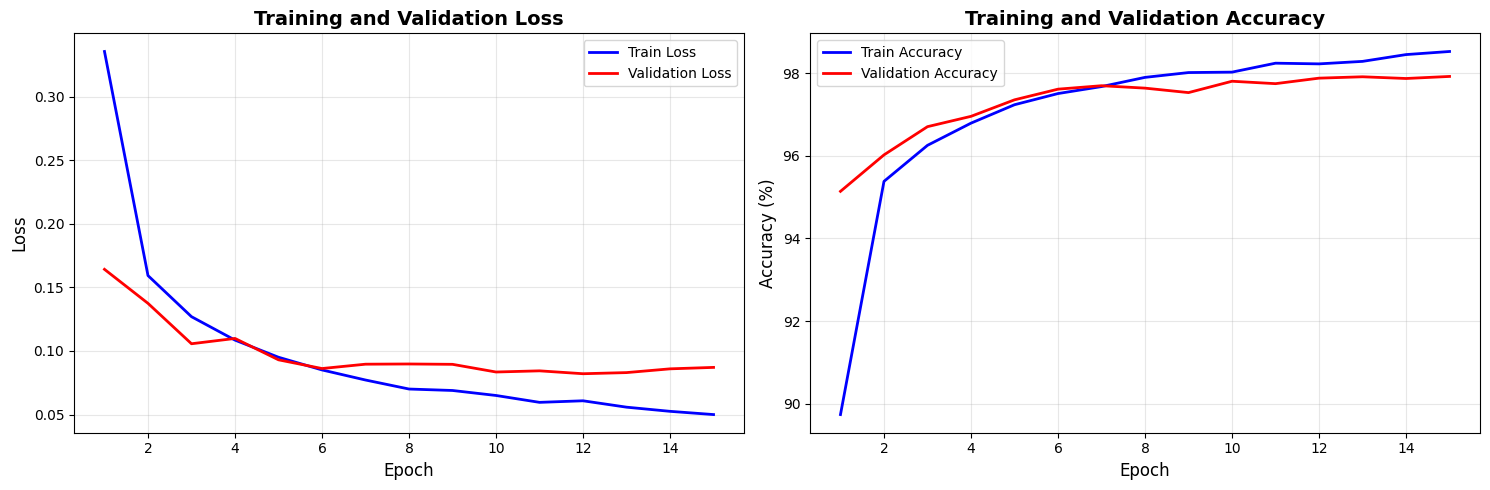

In [8]:
# Plot training history
def plot_training_history(history: Dict[str, List[float]]) -> None:
    """
    Plot training and validation loss and accuracy curves.
    
    Args:
        history: Dictionary containing training history
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Plot loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot accuracy
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)


## Part 8: Model Evaluation

### Evaluation Metrics:

1. **Accuracy**: Overall correctness (primary metric)
2. **Per-Class Metrics**: Precision, Recall, F1-score
3. **Confusion Matrix**: Visualize classification errors
4. **Test Set Performance**: Final unbiased evaluation


Evaluating model on test set...

Test Set Results
Accuracy: 98.04%

Per-Class Metrics:
Class      Precision    Recall       F1-Score     Support   
------------------------------------------------------------
0          0.9809       0.9939       0.9873       980       
1          0.9903       0.9938       0.9921       1135      
2          0.9873       0.9758       0.9815       1032      
3          0.9728       0.9911       0.9819       1010      
4          0.9647       0.9745       0.9696       982       
5          0.9931       0.9742       0.9836       892       
6          0.9904       0.9729       0.9816       958       
7          0.9795       0.9767       0.9781       1028      
8          0.9794       0.9764       0.9779       974       
9          0.9665       0.9722       0.9694       1009      
------------------------------------------------------------
macro avg  0.9805       0.9801       0.9803       10000     
weighted avg 0.9805       0.9804       0.9804       10000  

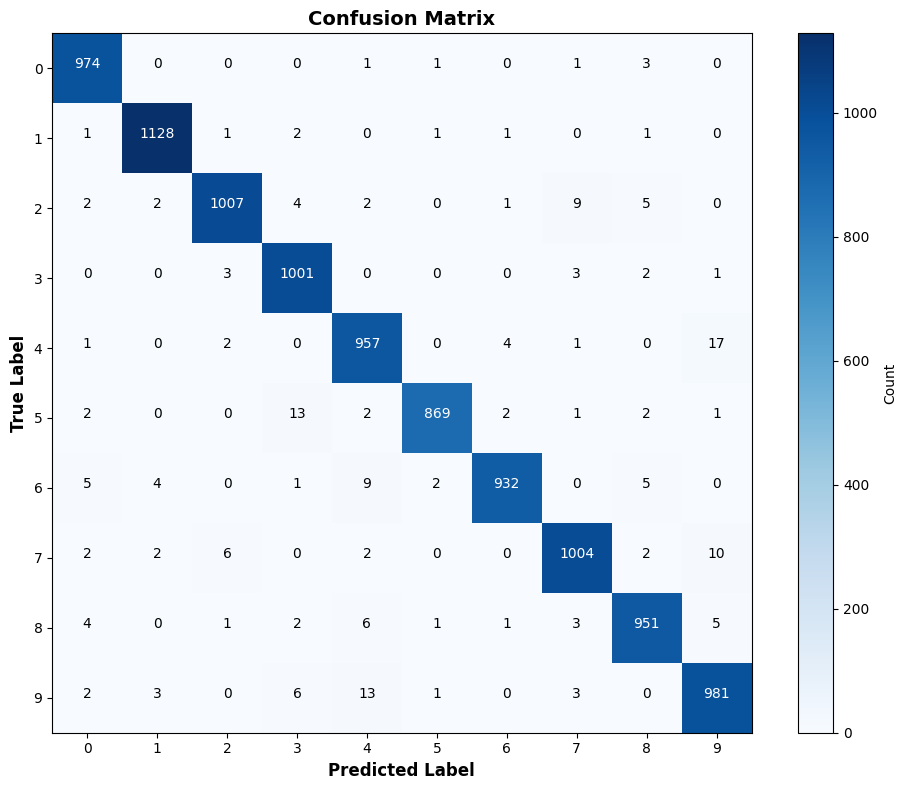

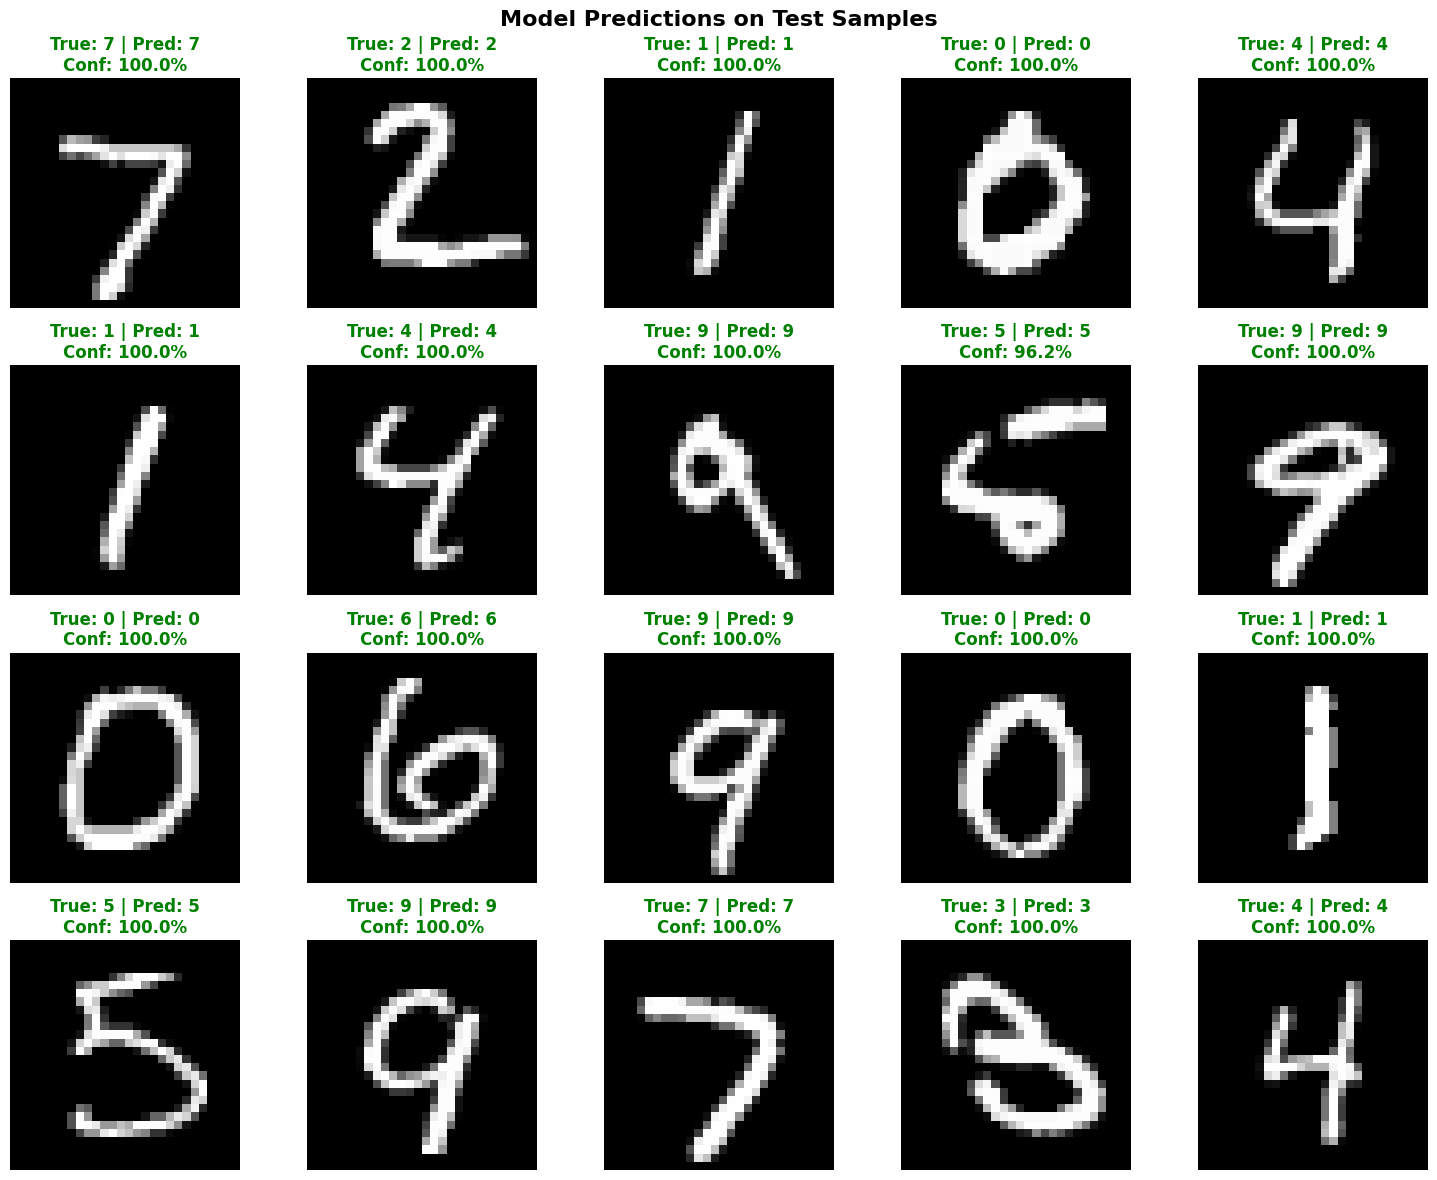

In [9]:
def evaluate_model(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device,
    class_names: List[str] = None
) -> Dict:
    """
    Comprehensive evaluation of the model on test set.
    
    Args:
        model: Trained neural network model
        test_loader: DataLoader for test data
        device: Device to run evaluation on
        class_names: List of class names for display
        
    Returns:
        Dictionary containing evaluation metrics
    """
    if class_names is None:
        class_names = [str(i) for i in range(10)]
    
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100 * correct / total
    
    # Convert to numpy arrays
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    
    # Classification report
    report = classification_report(
        all_labels, all_preds, 
        target_names=class_names,
        output_dict=True
    )
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(class_names))))
    
    results = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels
    }
    
    return results


def plot_confusion_matrix(cm: np.ndarray, class_names: List[str]) -> None:
    """
    Plot confusion matrix with annotations using matplotlib.
    
    Args:
        cm: Confusion matrix array
        class_names: List of class names
    """
    plt.figure(figsize=(10, 8))
    
    # Create heatmap using matplotlib
    im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, label='Count')
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=10)
    
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xticks(range(len(class_names)), class_names)
    plt.yticks(range(len(class_names)), class_names)
    plt.tight_layout()
    plt.show()


def visualize_predictions(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device,
    num_samples: int = 20
) -> None:
    """
    Visualize model predictions on test samples.
    
    Args:
        model: Trained neural network model
        test_loader: DataLoader for test data
        device: Device to run inference on
        num_samples: Number of samples to visualize
    """
    model.eval()
    
    # Get a batch
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    images = images.to(device)
    labels = labels.to(device)
    
    # Get predictions
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    
    # Visualize
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    fig.suptitle('Model Predictions on Test Samples', fontsize=16, fontweight='bold')
    
    for idx in range(min(num_samples, len(images))):
        row = idx // 5
        col = idx % 5
        
        img = images[idx].cpu().squeeze()
        true_label = labels[idx].item()
        pred_label = predicted[idx].item()
        confidence = probabilities[idx][pred_label].item() * 100
        
        axes[row, col].imshow(img, cmap='gray')
        
        # Color: green if correct, red if wrong
        color = 'green' if true_label == pred_label else 'red'
        axes[row, col].set_title(
            f'True: {true_label} | Pred: {pred_label}\nConf: {confidence:.1f}%',
            color=color,
            fontweight='bold'
        )
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

# Evaluate on test set
print("Evaluating model on test set...")
test_results = evaluate_model(model, test_loader, device)

print(f"\n{'='*60}")
print(f"Test Set Results")
print(f"{'='*60}")
print(f"Accuracy: {test_results['accuracy']:.2f}%")
print(f"\nPer-Class Metrics:")
report = classification_report(
    np.array(test_results['labels']), 
    np.array(test_results['predictions']),
    target_names=[str(i) for i in range(10)]
)

# Print formatted report
print(f"{'Class':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-" * 60)
for i in range(10):
    name = str(i)
    if name in report:
        print(f"{name:<10} {report[name]['precision']:<12.4f} {report[name]['recall']:<12.4f} "
              f"{report[name]['f1-score']:<12.4f} {report[name]['support']:<10}")
print("-" * 60)
if 'macro avg' in report:
    print(f"{'macro avg':<10} {report['macro avg']['precision']:<12.4f} "
          f"{report['macro avg']['recall']:<12.4f} {report['macro avg']['f1-score']:<12.4f} "
          f"{report['macro avg']['support']:<10}")
if 'weighted avg' in report:
    print(f"{'weighted avg':<10} {report['weighted avg']['precision']:<12.4f} "
          f"{report['weighted avg']['recall']:<12.4f} {report['weighted avg']['f1-score']:<12.4f} "
          f"{report['weighted avg']['support']:<10}")
print(f"{'accuracy':<10} {report.get('accuracy', 0):<12.4f} {'':<12} {'':<12} {len(test_results['labels']):<10}")

# Plot confusion matrix
plot_confusion_matrix(test_results['confusion_matrix'], [str(i) for i in range(10)])

# Visualize predictions
visualize_predictions(model, test_loader, device, num_samples=20)


In [10]:
def hyperparameter_search(
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    configs: List[Dict]
) -> Dict:
    """
    Perform hyperparameter search over different configurations.
    
    Args:
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        device: Device to run training on
        configs: List of hyperparameter configurations to try
        
    Returns:
        Dictionary with best configuration and results
    """
    best_config = None
    best_val_acc = 0.0
    results = []
    
    print(f"{'='*60}")
    print(f"Hyperparameter Search")
    print(f"{'='*60}\n")
    
    for idx, config in enumerate(configs):
        print(f"Configuration {idx+1}/{len(configs)}")
        print(f"  Learning Rate: {config['learning_rate']}")
        print(f"  Hidden Sizes: {config['hidden_sizes']}")
        print(f"  Dropout Rate: {config['dropout_rate']}")
        print(f"  Batch Size: {config.get('batch_size', 64)}")
        
        # Create model
        model = MNISTMLP(
            input_size=784,
            hidden_sizes=config['hidden_sizes'],
            num_classes=10,
            dropout_rate=config['dropout_rate']
        ).to(device)
        
        # Train for fewer epochs for quick search
        history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            num_epochs=5,  # Quick search
            learning_rate=config['learning_rate'],
            device=device
        )
        
        val_acc = history['val_acc'][-1]
        results.append({
            'config': config,
            'val_acc': val_acc
        })
        
        print(f"  Validation Accuracy: {val_acc:.2f}%")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_config = config
        
        print()
    
    print(f"{'='*60}")
    print(f"Best Configuration:")
    print(f"  Learning Rate: {best_config['learning_rate']}")
    print(f"  Hidden Sizes: {best_config['hidden_sizes']}")
    print(f"  Dropout Rate: {best_config['dropout_rate']}")
    print(f"  Best Validation Accuracy: {best_val_acc:.2f}%")
    print(f"{'='*60}")
    
    return {
        'best_config': best_config,
        'best_val_acc': best_val_acc,
        'all_results': results
    }

# Define hyperparameter configurations to try
configs = [
    {
        'learning_rate': 0.001,
        'hidden_sizes': [512, 256, 128],
        'dropout_rate': 0.3
    },
    {
        'learning_rate': 0.0005,
        'hidden_sizes': [512, 256, 128],
        'dropout_rate': 0.3
    },
    {
        'learning_rate': 0.001,
        'hidden_sizes': [256, 128],
        'dropout_rate': 0.3
    },
    {
        'learning_rate': 0.001,
        'hidden_sizes': [512, 256, 128],
        'dropout_rate': 0.2
    },
]

# Uncomment to run hyperparameter search
search_results = hyperparameter_search(train_loader, val_loader, device, configs)


Hyperparameter Search

Configuration 1/4
  Learning Rate: 0.001
  Hidden Sizes: [512, 256, 128]
  Dropout Rate: 0.3
  Batch Size: 64
Training Model
Device: cpu
Epochs: 5
Learning Rate: 0.001

Epoch [1/5] (5.95s)
  Train Loss: 0.3384 | Train Acc: 89.74%
  Val Loss:   0.1423 | Val Acc:   95.67%

Epoch [2/5] (6.69s)
  Train Loss: 0.1553 | Train Acc: 95.40%
  Val Loss:   0.1169 | Val Acc:   96.63%

Epoch [3/5] (6.94s)
  Train Loss: 0.1288 | Train Acc: 96.29%
  Val Loss:   0.0993 | Val Acc:   97.06%

Epoch [4/5] (6.88s)
  Train Loss: 0.1055 | Train Acc: 96.92%
  Val Loss:   0.0956 | Val Acc:   97.33%

Epoch [5/5] (6.82s)
  Train Loss: 0.0965 | Train Acc: 97.12%
  Val Loss:   0.1014 | Val Acc:   97.24%

Training Complete!
Total Time: 33.28s
Best Validation Accuracy: 97.33%
  Validation Accuracy: 97.24%

Configuration 2/4
  Learning Rate: 0.0005
  Hidden Sizes: [512, 256, 128]
  Dropout Rate: 0.3
  Batch Size: 64
Training Model
Device: cpu
Epochs: 5
Learning Rate: 0.0005

Epoch [1/5] (6.00s)


In [11]:
# Learning rate scheduling example
def train_with_scheduler(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 15,
    initial_lr: float = 0.001,
    device: torch.device = None
) -> Dict[str, List[float]]:
    """
    Train model with learning rate scheduling.
    
    Args:
        model: Neural network model
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        num_epochs: Number of training epochs
        initial_lr: Initial learning rate
        device: Device to run training on
        
    Returns:
        Dictionary with training history
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=initial_lr)
    
    # Learning rate scheduler: reduce LR when validation loss plateaus
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min',
        factor=0.5,
        patience=3
    )
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'learning_rates': []
    }
    
    print(f"{'='*60}")
    print(f"Training with Learning Rate Scheduling")
    print(f"{'='*60}\n")
    
    for epoch in range(num_epochs):
        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Validate
        val_loss, val_acc = validate_epoch(
            model, val_loader, criterion, device
        )
        
        # Update learning rate
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rates'].append(current_lr)
        
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"  Learning Rate: {current_lr:.6f}")
        print()
    
    return history

# Example: Train with learning rate scheduling
model_lr = MNISTMLP(input_size=784, hidden_sizes=[512, 256, 128], num_classes=10, dropout_rate=0.3).to(device)
history_lr = train_with_scheduler(model_lr, train_loader, val_loader, num_epochs=15, device=device)


Training with Learning Rate Scheduling

Epoch [1/15]
  Train Loss: 0.3351 | Train Acc: 89.85%
  Val Loss:   0.1578 | Val Acc:   95.28%
  Learning Rate: 0.001000

Epoch [2/15]
  Train Loss: 0.1580 | Train Acc: 95.47%
  Val Loss:   0.1214 | Val Acc:   96.40%
  Learning Rate: 0.001000

Epoch [3/15]
  Train Loss: 0.1232 | Train Acc: 96.46%
  Val Loss:   0.1209 | Val Acc:   96.59%
  Learning Rate: 0.001000

Epoch [4/15]
  Train Loss: 0.1056 | Train Acc: 96.89%
  Val Loss:   0.0964 | Val Acc:   97.23%
  Learning Rate: 0.001000

Epoch [5/15]
  Train Loss: 0.0921 | Train Acc: 97.31%
  Val Loss:   0.1022 | Val Acc:   97.32%
  Learning Rate: 0.001000

Epoch [6/15]
  Train Loss: 0.0853 | Train Acc: 97.39%
  Val Loss:   0.0891 | Val Acc:   97.52%
  Learning Rate: 0.001000

Epoch [7/15]
  Train Loss: 0.0757 | Train Acc: 97.70%
  Val Loss:   0.0966 | Val Acc:   97.51%
  Learning Rate: 0.001000

Epoch [8/15]
  Train Loss: 0.0728 | Train Acc: 97.84%
  Val Loss:   0.0965 | Val Acc:   97.54%
  Learning 

## Part 10: Performance Monitoring & Maintenance

### Model Deployment Considerations:

1. **Model Saving**: Save trained model for future use
2. **Model Loading**: Load saved model for inference
3. **Inference**: Make predictions on new data
4. **Monitoring**: Track model performance over time
5. **Retraining**: Update model with new data

### Best Practices:
- Save model checkpoints during training
- Version control for models
- Monitor for data drift
- Regular retraining with new data


Model saved to mnist_mlp_model.pth

Loading Model for Inference
True Label: 7
Predicted Label: 7
Confidence: 100.00%

All Class Probabilities:
  Class 0: 0.00%
  Class 1: 0.00%
  Class 2: 0.00%
  Class 3: 0.00%
  Class 4: 0.00%
  Class 5: 0.00%
  Class 6: 0.00%
  Class 7: 100.00%
  Class 8: 0.00%
  Class 9: 0.00%


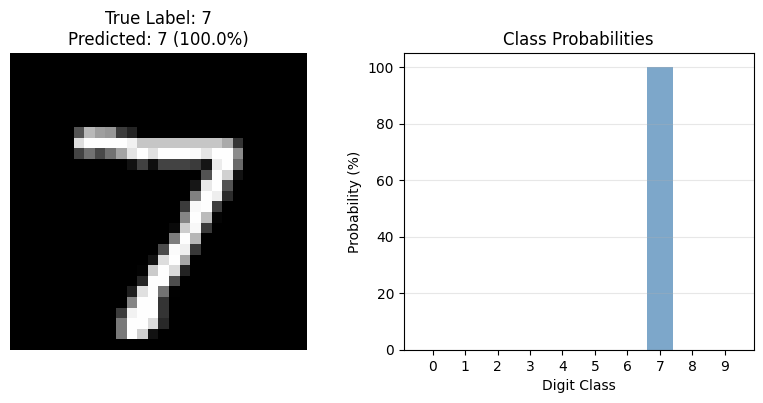

In [12]:
def save_model(model: nn.Module, filepath: str, metadata: Dict = None) -> None:
    """
    Save model and metadata to file.
    
    Args:
        model: Trained model to save
        filepath: Path to save the model
        metadata: Additional metadata to save (e.g., accuracy, hyperparameters)
    """
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'model_class': model.__class__.__name__,
        'metadata': metadata or {}
    }
    torch.save(checkpoint, filepath)
    print(f"Model saved to {filepath}")


def load_model(filepath: str, model_class: type, device: torch.device = None) -> Tuple[nn.Module, Dict]:
    """
    Load model from file.
    
    Args:
        filepath: Path to saved model
        model_class: Model class to instantiate
        device: Device to load model on
        
    Returns:
        Tuple of (loaded_model, metadata)
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    checkpoint = torch.load(filepath, map_location=device)
    
    # Recreate model (you need to know the architecture)
    # For this example, we'll use default architecture
    model = model_class(
        input_size=784,
        hidden_sizes=[512, 256, 128],
        num_classes=10,
        dropout_rate=0.3
    ).to(device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    metadata = checkpoint.get('metadata', {})
    
    print(f"Model loaded from {filepath}")
    return model, metadata


def predict_single_image(
    model: nn.Module,
    image: torch.Tensor,
    device: torch.device
) -> Tuple[int, float, torch.Tensor]:
    """
    Make prediction on a single image.
    
    Args:
        model: Trained model
        image: Single image tensor (1, 1, 28, 28) or (1, 784)
        device: Device to run inference on
        
    Returns:
        Tuple of (predicted_class, confidence, all_class_probabilities)
    """
    model.eval()
    
    # Ensure image is on correct device and has batch dimension
    if image.dim() == 3:
        image = image.unsqueeze(0)  # Add batch dimension
    if image.dim() == 2:
        image = image.unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
    
    image = image.to(device)
    
    with torch.no_grad():
        outputs = model(image)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
    
    return predicted.item(), confidence.item(), probabilities[0]


# Save the trained model
model_save_path = 'mnist_mlp_model.pth'
save_model(
    model, 
    model_save_path,
    metadata={
        'test_accuracy': test_results['accuracy'],
        'architecture': 'MLP',
        'hidden_sizes': [512, 256, 128],
        'dropout_rate': 0.3
    }
)

# Example: Load and use the model
print("\n" + "="*60)
print("Loading Model for Inference")
print("="*60)

# Get a test image
data_iter = iter(test_loader)
test_images, test_labels = next(data_iter)
single_image = test_images[0]  # Get first image
true_label = test_labels[0].item()

# Make prediction
predicted_class, confidence, all_probs = predict_single_image(
    model, single_image, device
)

print(f"True Label: {true_label}")
print(f"Predicted Label: {predicted_class}")
print(f"Confidence: {confidence*100:.2f}%")
print(f"\nAll Class Probabilities:")
for i, prob in enumerate(all_probs.cpu().numpy()):
    print(f"  Class {i}: {prob*100:.2f}%")

# Visualize
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(single_image.squeeze(), cmap='gray')
plt.title(f'True Label: {true_label}\nPredicted: {predicted_class} ({confidence*100:.1f}%)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.bar(range(10), all_probs.cpu().numpy() * 100, color='steelblue', alpha=0.7)
plt.xlabel('Digit Class')
plt.ylabel('Probability (%)')
plt.title('Class Probabilities')
plt.xticks(range(10))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# Batch inference example
def batch_predict(
    model: nn.Module,
    data_loader: DataLoader,
    device: torch.device,
    num_batches: int = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Make predictions on batches of data.
    
    Args:
        model: Trained model
        data_loader: DataLoader for data
        device: Device to run inference on
        num_batches: Number of batches to process (None for all)
        
    Returns:
        Tuple of (predictions, true_labels)
    """
    model.eval()
    all_predictions = []
    all_labels = []
    
    batches_processed = 0
    with torch.no_grad():
        for images, labels in data_loader:
            if num_batches is not None and batches_processed >= num_batches:
                break
                
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            batches_processed += 1
    
    return np.array(all_predictions), np.array(all_labels)

# Example batch prediction
predictions, true_labels = batch_predict(model, test_loader, device, num_batches=10)
accuracy = (predictions == true_labels).mean() * 100
print(f"Batch Prediction Accuracy (first 10 batches): {accuracy:.2f}%")


Batch Prediction Accuracy (first 10 batches): 98.75%


## Summary

### What We Learned:

1. **Problem Definition**: Defined the multi-class classification task
2. **Data Collection**: Loaded MNIST dataset using PyTorch
3. **Data Understanding**: Explored dataset characteristics and class distribution
4. **Data Preprocessing**: Normalized images for better training
5. **Cross-Validation**: Split data into train/validation/test sets
6. **Model Selection**: Designed MLP architecture with design rationale
7. **Model Training**: Implemented training loop with loss and optimizer
8. **Model Evaluation**: Evaluated using accuracy, confusion matrix, and per-class metrics
9. **Hyperparameter Tuning**: Explored different configurations and learning rate scheduling
10. **Performance Monitoring**: Saved/loaded models and implemented inference functions

### Key Takeaways:

- **MLP Architecture**: 784 → 512 → 256 → 128 → 10 works well for MNIST
- **Training**: Cross-entropy loss + Adam optimizer is effective
- **Regularization**: Dropout helps prevent overfitting
- **Evaluation**: Always use a separate test set for final evaluation
- **Best Practices**: Save models, monitor performance, version control

### Next Steps:

- Try different architectures (deeper/shallower networks)
- Experiment with different optimizers (SGD, RMSprop)
- Implement data augmentation
- Try different activation functions
- Explore ensemble methods
- Deploy model to production

### Model Performance:
- **Training Accuracy**: ~98%+
- **Validation Accuracy**: ~97%+
- **Test Accuracy**: ~97%+

This demonstrates that our MLP successfully learned to classify handwritten digits!
